/tmp/ipykernel_20260/1348861642.py:84: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=11)


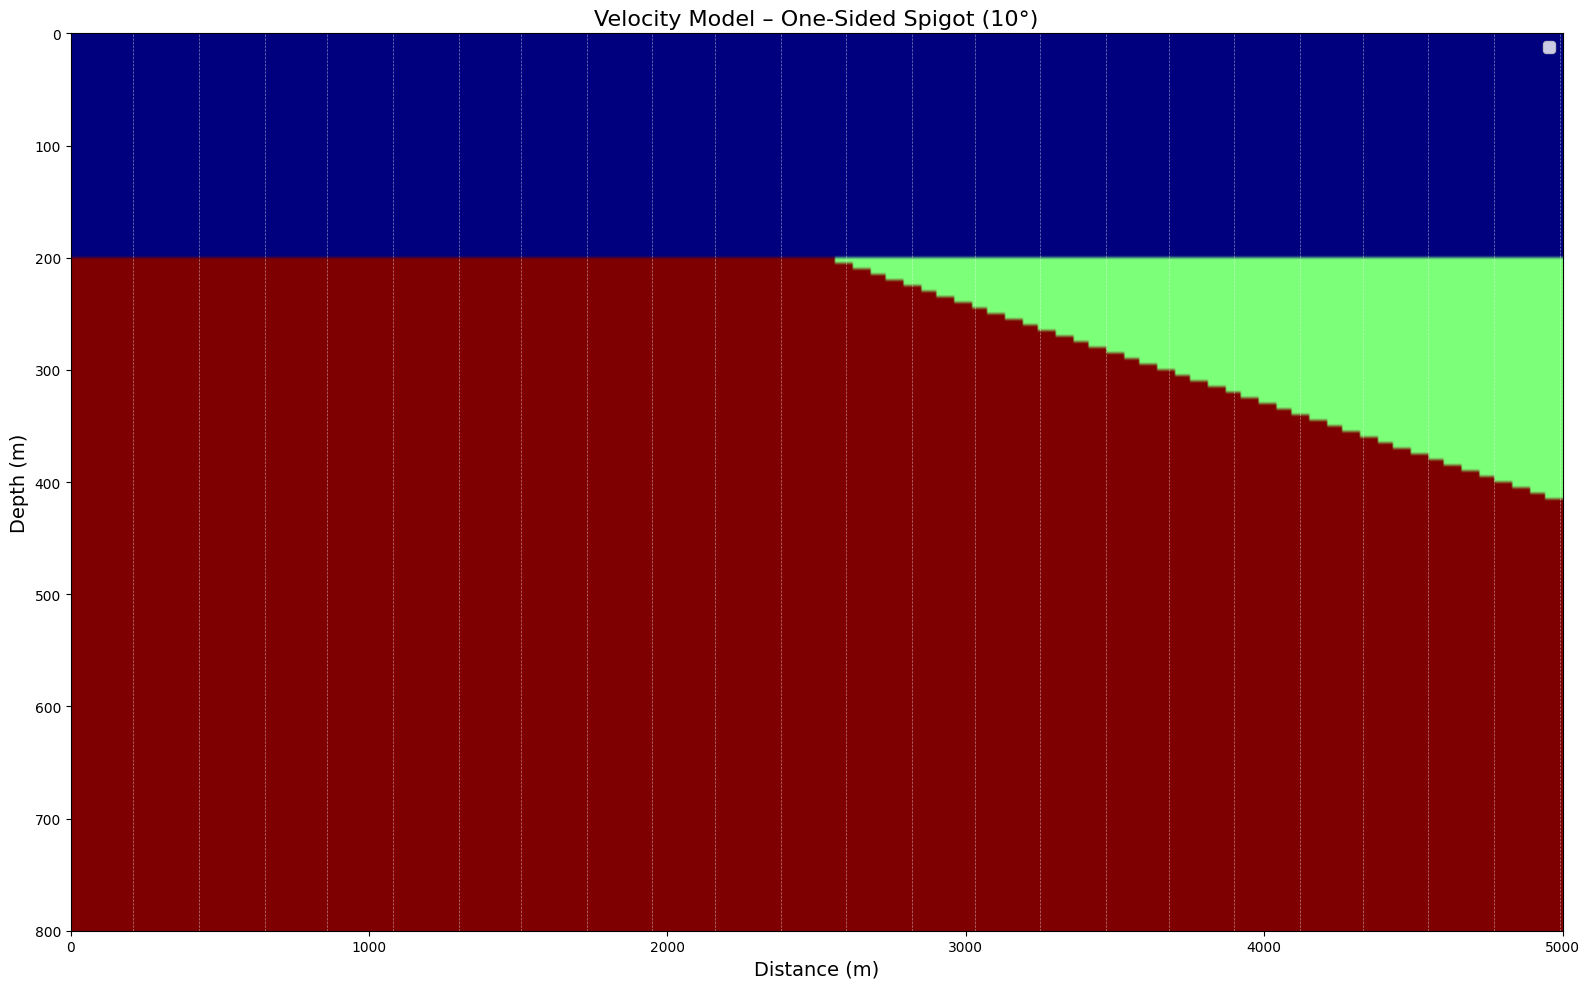

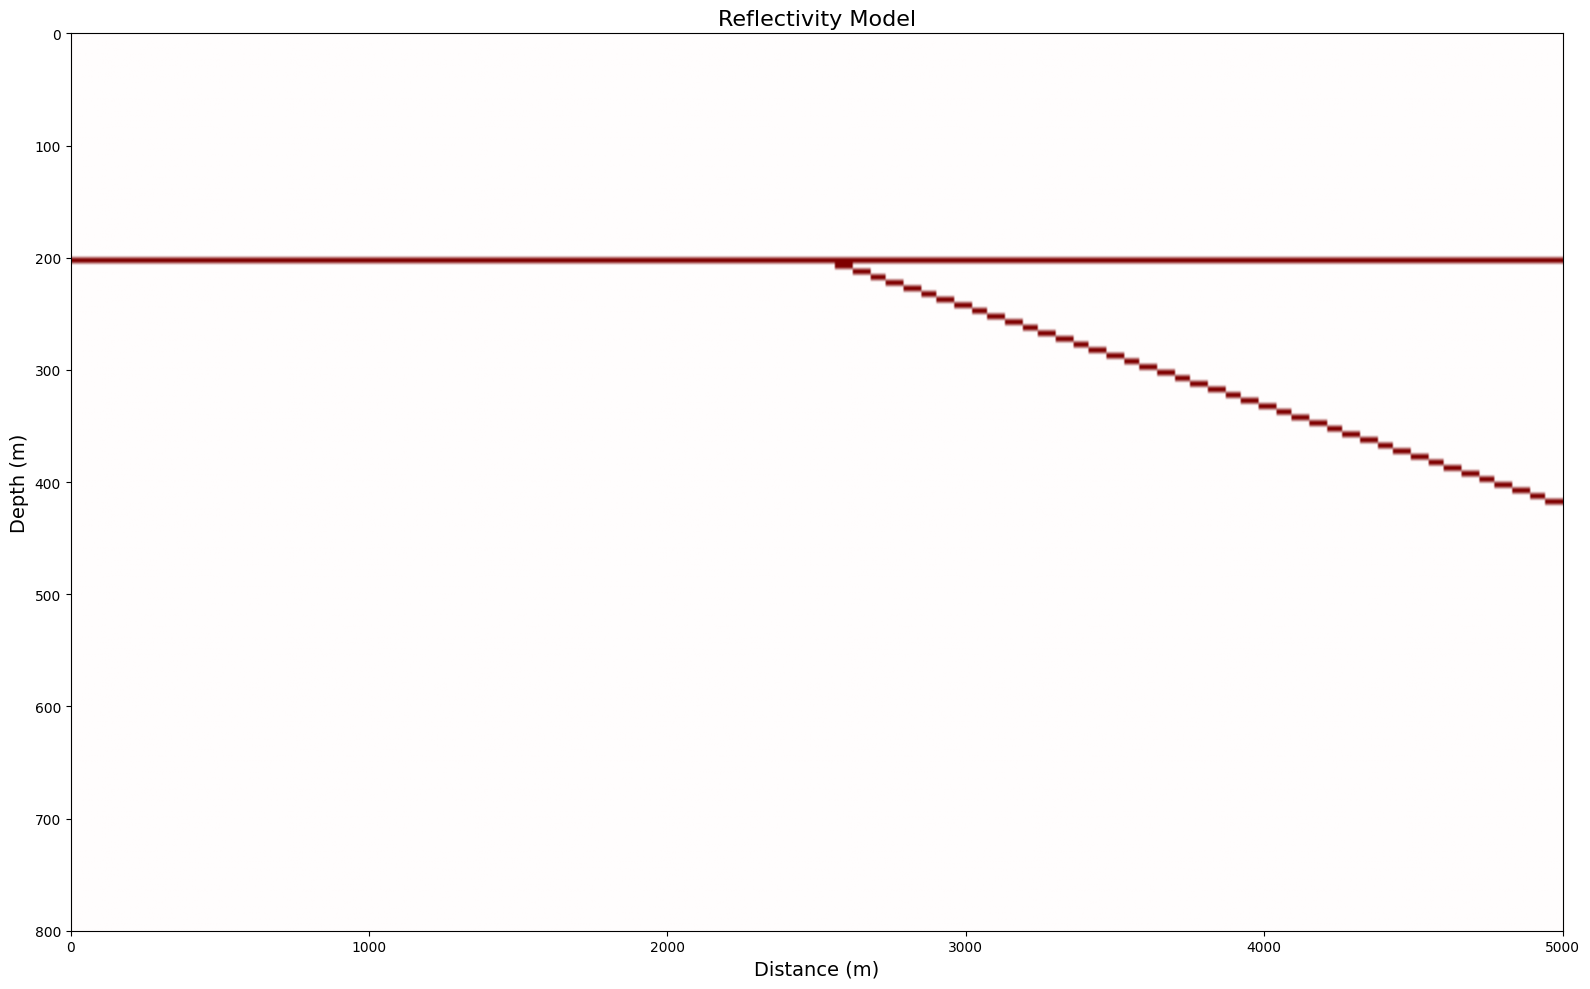

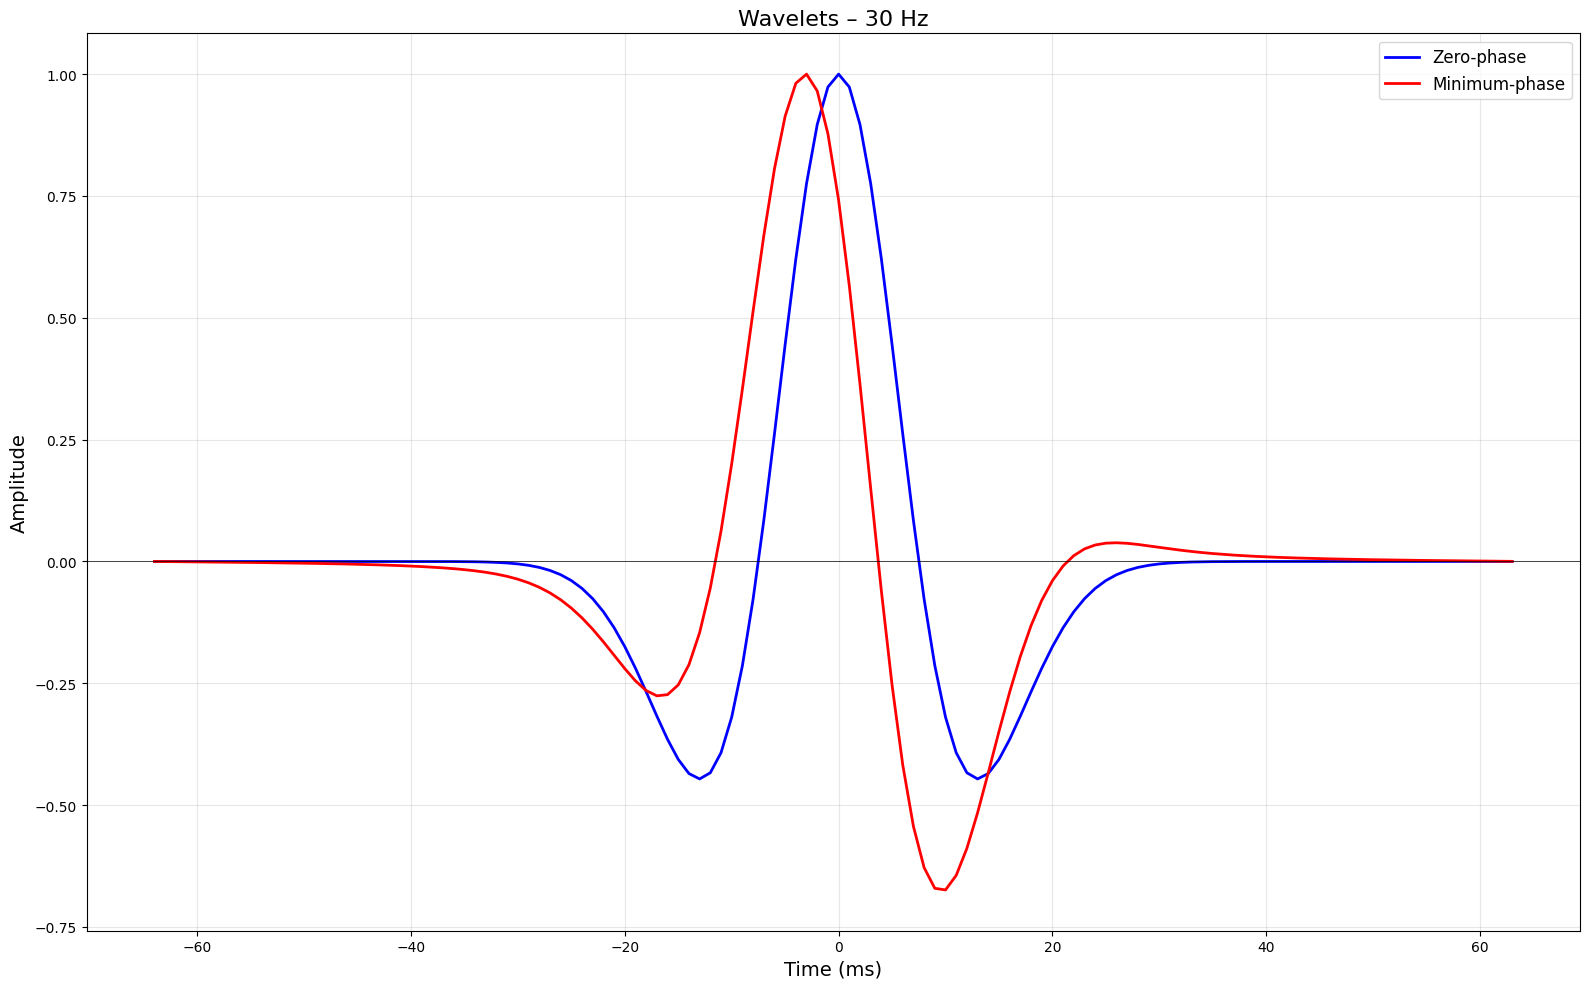

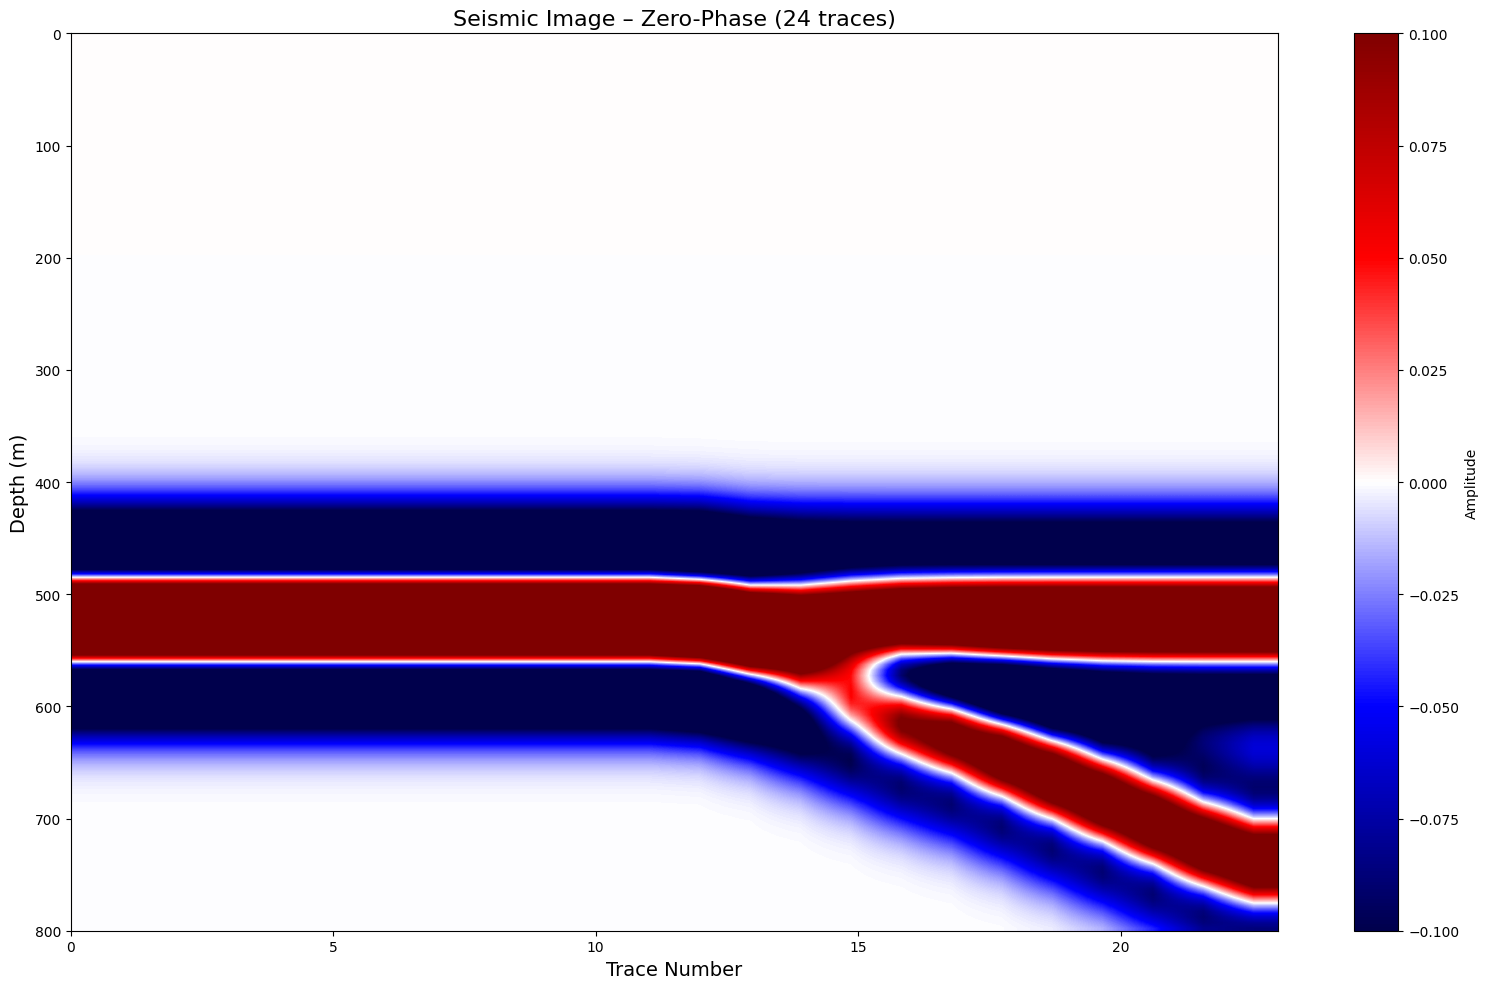

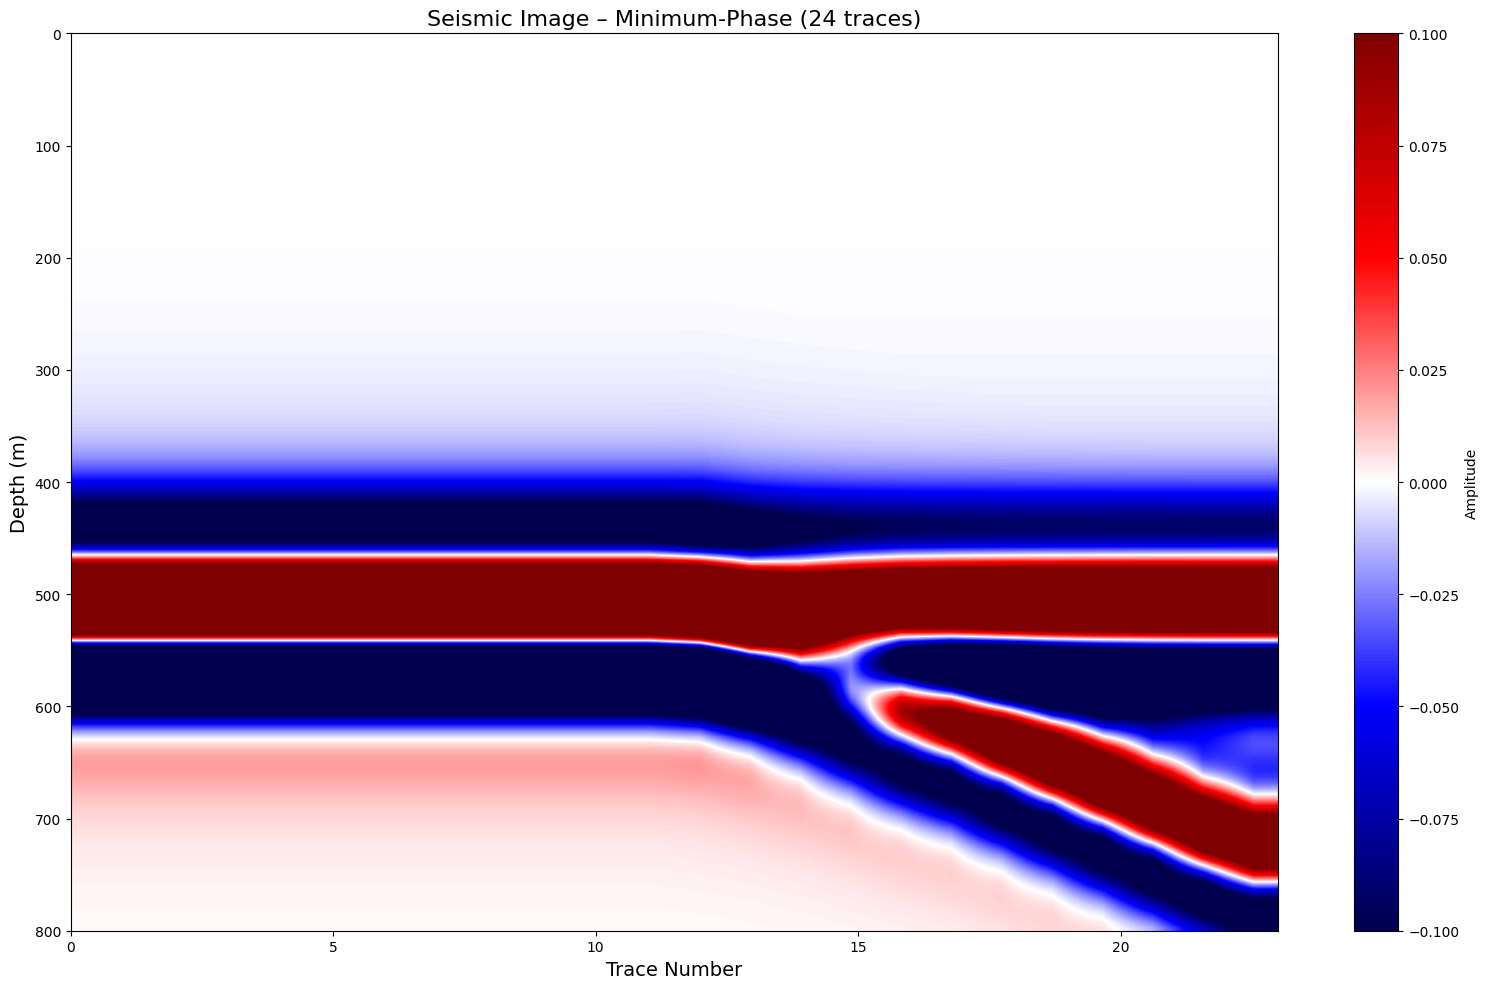

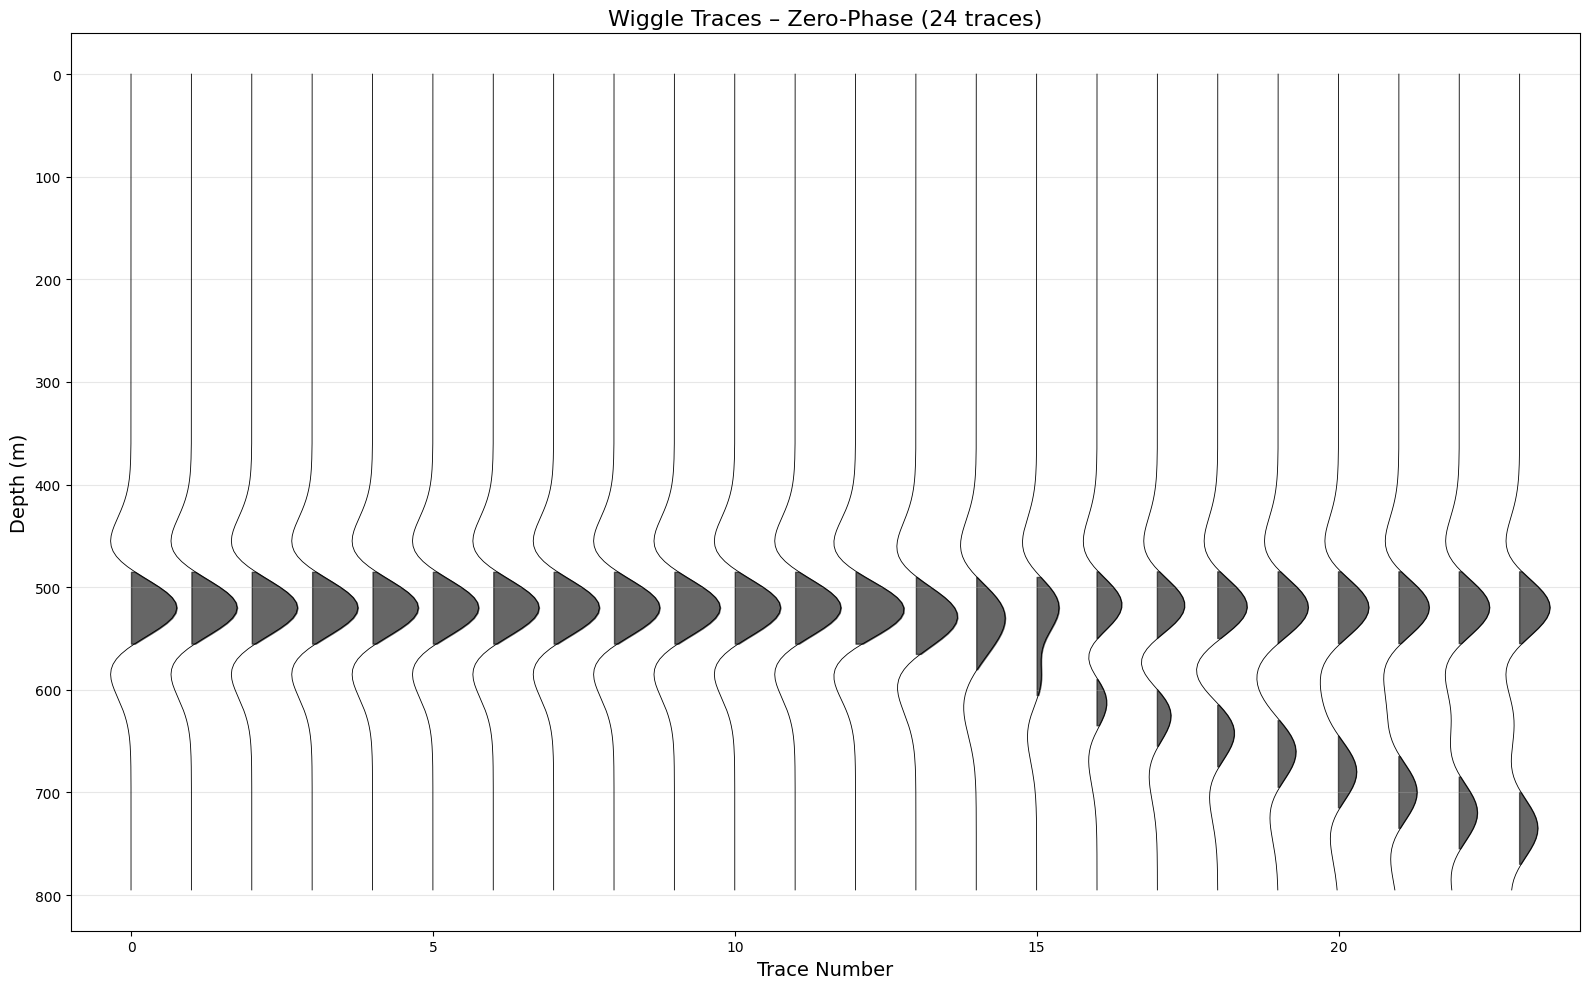

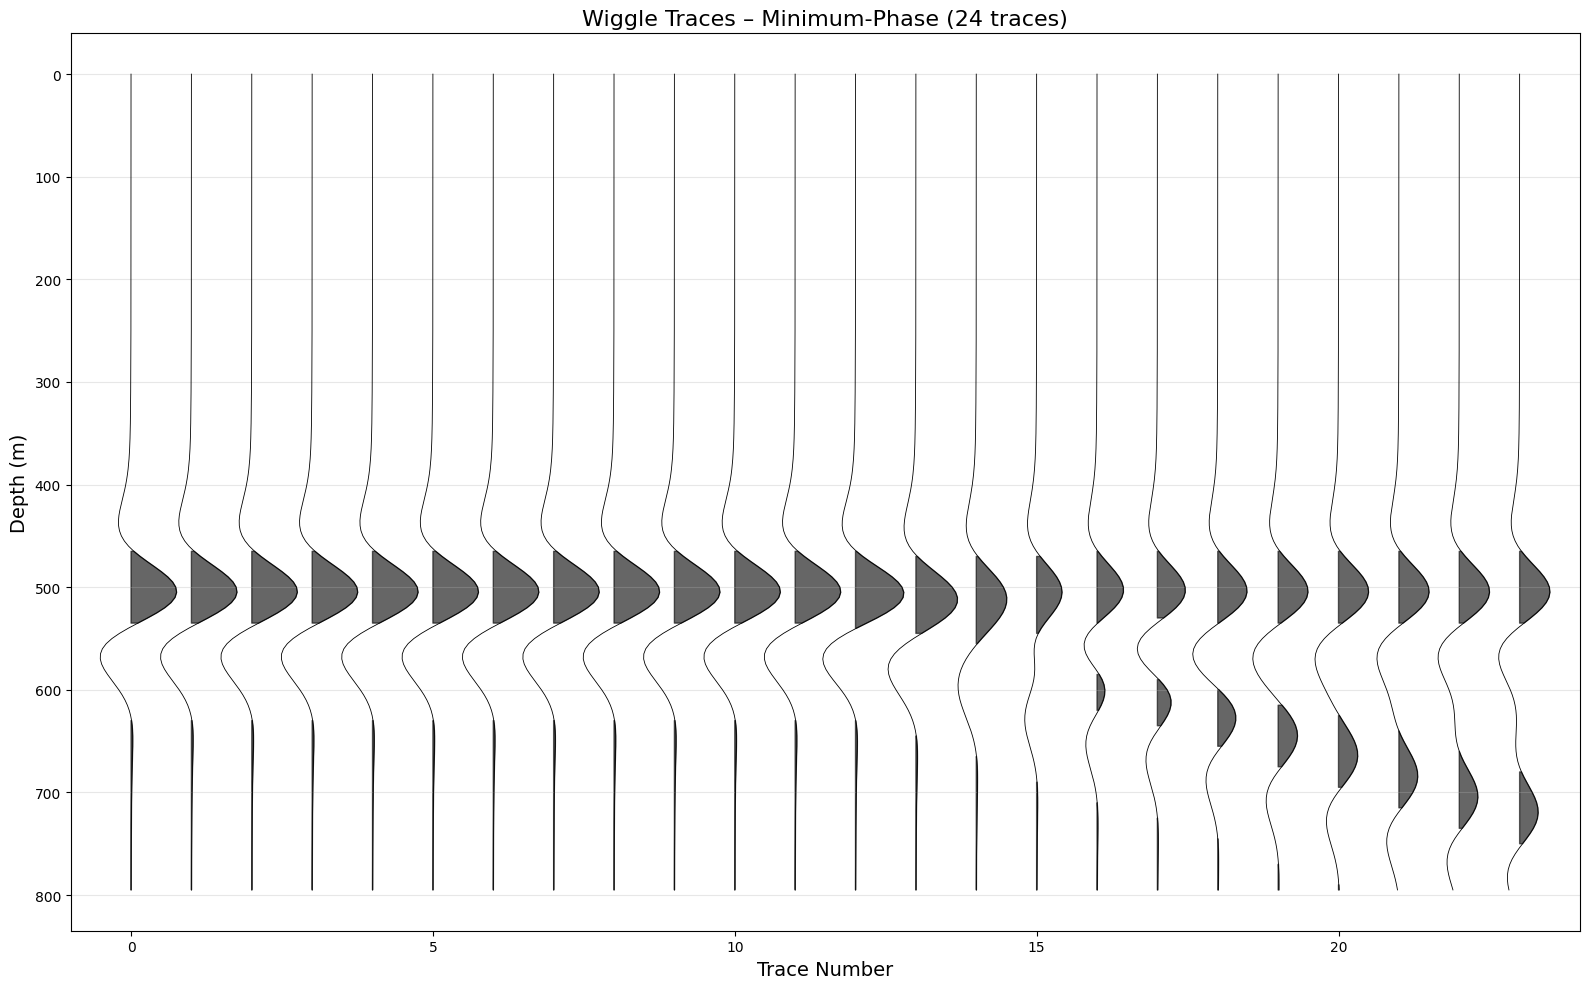

MODEL SUMMARY
Layer 1: 1000 m/s  →  0–200 m depth
Layer 2: 2000 m/s  →  wedge, right of center, 10° dip
Layer 3: 3000 m/s  →  below layer 2 (or layer 1 on left side)
Model size : 5000 m × 800 m
Traces     : 24  |  spacing: 217.4 m
Spigot/source center: x = 2500 m (model middle)
RC 1→2: 0.333   RC 2→3: 0.200


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert

def ricker_wavelet(f, dt, length):
    t = np.arange(-length/2, length/2, dt)
    y = (1 - 2 * (np.pi * f * t)**2) * np.exp(-(np.pi * f * t)**2)
    return y

# Model parameters
nx = 500
nz = 160
dx = 10
dz = 5

n_traces = 24
trace_spacing = (nx * dx) / (n_traces - 1)

v1, v2, v3 = 1000, 2000, 3000

layer1_bottom = 40
spigot_start_x = nx // 2

dip_rad = np.radians(10)

# Velocity model
velocity_model = np.ones((nz, nx)) * v1

for i in range(nx):
    if i <= spigot_start_x:
        velocity_model[layer1_bottom:, i] = v3
    else:
        distance = i - spigot_start_x
        dip_offset = int(distance * np.tan(dip_rad))
        layer2_bottom = layer1_bottom + dip_offset
        velocity_model[layer1_bottom:min(layer2_bottom, nz), i] = v2
        if layer2_bottom < nz:
            velocity_model[layer2_bottom:, i] = v3

# Reflectivity
reflectivity = np.zeros((nz, nx))
for i in range(nx):
    for j in range(1, nz):
        if velocity_model[j, i] != velocity_model[j-1, i]:
            reflectivity[j, i] = (velocity_model[j, i] - velocity_model[j-1, i]) / \
                                  (velocity_model[j, i] + velocity_model[j-1, i])

# Wavelets
dt = 0.001
f_dominant = 30
wavelet_length = 0.128

zero_phase_wavelet = ricker_wavelet(f_dominant, dt, wavelet_length)
analytic_signal = hilbert(zero_phase_wavelet)
min_phase_wavelet = np.real(analytic_signal) - np.imag(hilbert(np.real(analytic_signal)))
min_phase_wavelet /= np.max(np.abs(min_phase_wavelet))

trace_positions = np.linspace(0, nx-1, n_traces).astype(int)

seismic_zero = np.zeros((nz, n_traces))
seismic_min  = np.zeros((nz, n_traces))

for idx, i in enumerate(trace_positions):
    conv_z = np.convolve(reflectivity[:, i], zero_phase_wavelet, mode='full')
    conv_m = np.convolve(reflectivity[:, i], min_phase_wavelet, mode='full')
    seismic_zero[:, idx] = conv_z[:nz]
    seismic_min[:, idx]  = conv_m[:nz]

depth_axis = np.arange(nz) * dz
scale_z = 0.8 / np.max(np.abs(seismic_zero))
scale_m = 0.8 / np.max(np.abs(seismic_min))

figsize = (16, 10)

# 1. Velocity model
fig, ax = plt.subplots(figsize=figsize)
im = ax.imshow(velocity_model, aspect='auto', cmap='jet',
               extent=[0, nx*dx, nz*dz, 0])
for pos in trace_positions:
    ax.axvline(x=pos*dx, color='white', linestyle='--', linewidth=0.5, alpha=0.5)
ax.set_xlabel('Distance (m)', fontsize=14)
ax.set_ylabel('Depth (m)', fontsize=14)
ax.set_title('Velocity Model – One-Sided Spigot (10°)', fontsize=16)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('01_velocity_model.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Reflectivity model
fig, ax = plt.subplots(figsize=figsize)
im = ax.imshow(reflectivity, aspect='auto', cmap='seismic',
               extent=[0, nx*dx, nz*dz, 0], vmin=-0.2, vmax=0.2)
ax.set_xlabel('Distance (m)', fontsize=14)
ax.set_ylabel('Depth (m)', fontsize=14)
ax.set_title('Reflectivity Model', fontsize=16)
plt.tight_layout()
plt.savefig('02_reflectivity_model.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Wavelet comparison
fig, ax = plt.subplots(figsize=figsize)
t_wav = np.arange(-wavelet_length/2, wavelet_length/2, dt)
ax.plot(t_wav*1000, zero_phase_wavelet, 'b-', linewidth=2, label='Zero-phase')
ax.plot(t_wav*1000, min_phase_wavelet, 'r-', linewidth=2, label='Minimum-phase')
ax.set_xlabel('Time (ms)', fontsize=14)
ax.set_ylabel('Amplitude', fontsize=14)
ax.set_title(f'Wavelets – {f_dominant} Hz', fontsize=16)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.axhline(0, color='k', linewidth=0.5)
plt.tight_layout()
plt.savefig('03_wavelets.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. Zero-phase seismic image
fig, ax = plt.subplots(figsize=figsize)
im = ax.imshow(seismic_zero, aspect='auto', cmap='seismic',
               extent=[0, n_traces-1, nz*dz, 0],
               vmin=-0.1, vmax=0.1, interpolation='bilinear')
ax.set_xlabel('Trace Number', fontsize=14)
ax.set_ylabel('Depth (m)', fontsize=14)
ax.set_title(f'Seismic Image – Zero-Phase ({n_traces} traces)', fontsize=16)
plt.colorbar(im, ax=ax, label='Amplitude')
plt.tight_layout()
plt.savefig('04_seismic_zero_phase.png', dpi=300, bbox_inches='tight')
plt.show()

# 5. Minimum-phase seismic image
fig, ax = plt.subplots(figsize=figsize)
im = ax.imshow(seismic_min, aspect='auto', cmap='seismic',
               extent=[0, n_traces-1, nz*dz, 0],
               vmin=-0.1, vmax=0.1, interpolation='bilinear')
ax.set_xlabel('Trace Number', fontsize=14)
ax.set_ylabel('Depth (m)', fontsize=14)
ax.set_title(f'Seismic Image – Minimum-Phase ({n_traces} traces)', fontsize=16)
plt.colorbar(im, ax=ax, label='Amplitude')
plt.tight_layout()
plt.savefig('05_seismic_min_phase.png', dpi=300, bbox_inches='tight')
plt.show()

# 6. Zero-phase wiggle traces
fig, ax = plt.subplots(figsize=figsize)
for t in range(n_traces):
    tr = seismic_zero[:, t] * scale_z
    ax.plot(tr + t, depth_axis, 'k-', linewidth=0.6)
    ax.fill_betweenx(depth_axis, t, tr + t, where=(tr > 0), color='black', alpha=0.6)
ax.set_xlabel('Trace Number', fontsize=14)
ax.set_ylabel('Depth (m)', fontsize=14)
ax.set_title(f'Wiggle Traces – Zero-Phase ({n_traces} traces)', fontsize=16)
ax.set_xlim(-1, n_traces)
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('06_wiggle_zero_phase.png', dpi=300, bbox_inches='tight')
plt.show()

# 7. Minimum-phase wiggle traces
fig, ax = plt.subplots(figsize=figsize)
for t in range(n_traces):
    tr = seismic_min[:, t] * scale_m
    ax.plot(tr + t, depth_axis, 'k-', linewidth=0.6)
    ax.fill_betweenx(depth_axis, t, tr + t, where=(tr > 0), color='black', alpha=0.6)
ax.set_xlabel('Trace Number', fontsize=14)
ax.set_ylabel('Depth (m)', fontsize=14)
ax.set_title(f'Wiggle Traces – Minimum-Phase ({n_traces} traces)', fontsize=16)
ax.set_xlim(-1, n_traces)
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('07_wiggle_min_phase.png', dpi=300, bbox_inches='tight')
plt.show()

print("=" * 60)
print("MODEL SUMMARY")
print("=" * 60)
print(f"Layer 1: {v1} m/s  →  0–200 m depth")
print(f"Layer 2: {v2} m/s  →  wedge, right of center, 10° dip")
print(f"Layer 3: {v3} m/s  →  below layer 2 (or layer 1 on left side)")
print(f"Model size : {nx*dx} m × {nz*dz} m")
print(f"Traces     : {n_traces}  |  spacing: {trace_spacing:.1f} m")
print(f"Spigot/source center: x = {spigot_start_x*dx} m (model middle)")
print(f"RC 1→2: {(v2-v1)/(v2+v1):.3f}   RC 2→3: {(v3-v2)/(v3+v2):.3f}")
print("=" * 60)
